In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import torch
sys.path.append('../../')

In [3]:
from neural_control.dynamics import SequentialDualSourcingModel, fractional_decoupling, binary_decoupling
from neural_control.demand_generators import FileBasedDemandGenerator
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy

torch.set_default_tensor_type(torch.cuda.FloatTensor)

In [4]:
service_type = 'high_service'

In [5]:
base_cofing = dict(h = 5, b = 495, cr = 0, ce = 20, lr = 2, le = 0)
service_configs = dict(high_service = dict(b=495), low_service = dict(b=95))

In [6]:
current_results = [
    dict(baselines='NNC', b=495, mean_cost=747117, median_cost=692118, method='current'),
    dict(baselines='CDI', b=495, mean_cost=773993, median_cost=770362, method='current'),
    dict(baselines='NNC', b=495, mean_cost=620968, median_cost=666600, method='future'),
    dict(baselines='CDI', b=495, mean_cost=722346, median_cost=716001, method='future'),    
    dict(baselines='NNC', b=95, mean_cost=583873, median_cost=563711, method='current'),
    dict(baselines='CDI', b=95, mean_cost=736018, median_cost=735265, method='current'),
    dict(baselines='NNC', b=95, mean_cost=564003, median_cost=541150, method='future'),
    dict(baselines='CDI', b=95, mean_cost=684495, median_cost=682958, method='future')
]
pd.DataFrame(current_results)

,baselines,b,mean_cost,median_cost,method
0,NNC,495,747117,692118,current
1,CDI,495,773993,770362,current
2,NNC,495,620968,666600,future
3,CDI,495,722346,716001,future
4,NNC,95,583873,563711,current
5,CDI,95,736018,735265,current
6,NNC,95,564003,541150,future
7,CDI,95,684495,682958,future


In [7]:
fbd = FileBasedDemandGenerator()

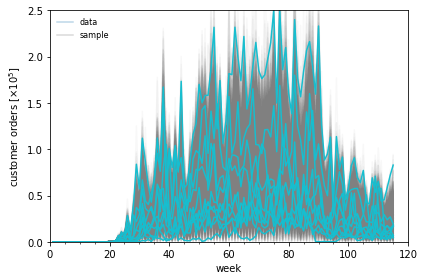

In [8]:
with np.errstate(divide='ignore', invalid='ignore'):
    #fbd.plot_gaussian_process_vs_model()
    #fbd.plot_distributions()
    fbd.plot_samples_vs_data()


In [9]:
sourcing_parameters = dict(T=fbd.max_weeks)
sourcing_parameters.update(base_cofing)
sourcing_parameters.update(service_configs['high_service'])

In [10]:
N = 1 # aka minibatch size
T = fbd.max_weeks

sds = SequentialDualSourcingModel(**sourcing_parameters)
sds.I_0 = torch.tensor(0.0, requires_grad=True)


In [11]:
class SequentialController(torch.nn.Module):
    def __init__(self, scaling_factor):
        super().__init__()
        self.sequential_layer = torch.nn.LSTM(input_size=1, hidden_size=38, num_layers=3, batch_first=True)
        self.scaling_factor = scaling_factor
        self.layer_norm = torch.nn.LayerNorm([T, 1])
        
    def forward(self, state):
        x = self.layer_norm(state)
        h, (h_T, c_T) =  self.sequential_layer(x)
        
        
        qr_quant = fractional_decoupling(torch.relu(h[:, :, 0]+1)*torch.exp(h[:, :, 1:18].sum(-1)))
        qr_dec = binary_decoupling(h[:, :, 18])
        
        qe_quant = fractional_decoupling(torch.relu(h[:, :, 19]+1)*torch.exp(h[:, :, 20:37].sum(-1)))
        qe_dec = binary_decoupling(h[:, :, 37])

        
        return qr_quant*qr_dec, qe_quant*qe_dec

In [12]:
sc = SequentialController(fbd.scaling_factor)

In [13]:
best_model = [deepcopy(sc.state_dict())]
best_cost = [np.infty]

In [14]:
optimizer = torch.optim.RMSprop(sc.parameters(), lr=5*1e-2)
optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)

In [15]:
N=128
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

In [16]:
future_demands.shape

torch.Size([128, 115])

In [17]:
sc.train()
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
demands = torch.cat([initial_demands, future_demands], dim=-1).float()
past_demands = demands[:, :-1]
compressed_input = (inital_inventories - past_demands).unsqueeze(-1)

for i in range(50000):
    optimizer.zero_grad()
    new_qr, new_qe = sc(compressed_input)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe
    
    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]
    
    
    
    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    mean_costs = costs.mean()
    J = mean_costs + (0.001*costs.max(dim=0).values).mean()
    

    
    J.backward()
    optimizer.step()
    
    if mean_costs.item() < best_cost[0] and i > 10000:
        best_cost[0] = mean_costs.item()
        best_model[0] = deepcopy(sc.state_dict())
    
    if i%500 == 0 and i > 0:
        optimizer = torch.optim.RMSprop(sc.parameters(), lr=5*1e-2)
        optimizer_i0 = torch.optim.RMSprop([sds.I_0], lr=1e-0)
        future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
        inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
        demands = torch.cat([initial_demands, future_demands], dim=-1).float()
        past_demands = demands[:, :-1]
        compressed_input = (fractional_decoupling(inital_inventories)  - past_demands).unsqueeze(-1)
        print(costs.mean())

tensor(18652698., grad_fn=<MeanBackward0>)
tensor(6552646., grad_fn=<MeanBackward0>)
tensor(4939013.5000, grad_fn=<MeanBackward0>)
tensor(7290124., grad_fn=<MeanBackward0>)
tensor(22504678., grad_fn=<MeanBackward0>)
tensor(5186531., grad_fn=<MeanBackward0>)
tensor(5025193., grad_fn=<MeanBackward0>)
tensor(5276975.5000, grad_fn=<MeanBackward0>)
tensor(4339507., grad_fn=<MeanBackward0>)
tensor(17355302., grad_fn=<MeanBackward0>)
tensor(5519267.5000, grad_fn=<MeanBackward0>)
tensor(5611778., grad_fn=<MeanBackward0>)
tensor(5715718.5000, grad_fn=<MeanBackward0>)
tensor(6234089.5000, grad_fn=<MeanBackward0>)
tensor(5789109., grad_fn=<MeanBackward0>)
tensor(6576306.5000, grad_fn=<MeanBackward0>)
tensor(6478097., grad_fn=<MeanBackward0>)
tensor(5703139., grad_fn=<MeanBackward0>)
tensor(6631420.5000, grad_fn=<MeanBackward0>)
tensor(4901338., grad_fn=<MeanBackward0>)
tensor(6525318.5000, grad_fn=<MeanBackward0>)
tensor(6437103., grad_fn=<MeanBackward0>)
tensor(5820933.5000, grad_fn=<MeanBackwar

In [18]:
best_cost

[4344509.0]

In [19]:
sc.load_state_dict(best_model[0])

<All keys matched successfully>

In [20]:
N=1024
sds.reset(N)
inital_inventories = fractional_decoupling(sds.I_0.repeat(N, 1))
initial_demands = sds.all_demands[0]
initial_qr = torch.cat(sds.previous_qr, dim=-1)
initial_qe = torch.cat(sds.previous_qe, dim=-1)
future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)

with torch.no_grad():
    sc.eval()
    future_demands = fbd.sample_trajectory(t=0, n_samples=N, n_timesteps=T)
    demands = torch.cat([initial_demands, future_demands], dim=-1).float()

    past_demands = demands[:, :-1]
    compressed_input = (inital_inventories - past_demands).unsqueeze(-1)
    new_qr, new_qe = sc(compressed_input)
    # new_qe = torch.randn([N, T]).abs().round()
    # new_qr = torch.randn([N, T]).abs().round()

    qr = torch.cat([initial_qr, new_qr], dim=-1) if sds.lr > 0 else new_qr
    qe = torch.cat([initial_qe, new_qe], dim=-1) if sds.le > 0 else new_qe

    qe_arrived = qe[:, :T]
    qr_arrived = qr[:, :T]

    qe_ordered = qe[:, sds.le:]
    qr_ordered = qr[:, sds.lr:]

    costs, invs = sds.replay_multisteps(inital_inventories, 
                                                    qra=qr_arrived,
                                                    qea=qe_arrived,
                                                    qro=qr_ordered,
                                                    qeo=qe_ordered,
                                                    all_demands=demands
                                                   )
    print('Mean: ' + str(costs.mean().item()))
    print('Median: ' + str(costs.median().item()))

Mean: 5336957.0
Median: 4732976.0


In [21]:
costs.mean()

tensor(5336957.)

In [22]:
(new_qe > 0).any()

tensor(True)

In [23]:
new_qr

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [24]:
costs

tensor([[       0.0000,        0.0000,        0.0000,  ...,
          5983061.0000,  4966743.5000,  5979693.0000],
        [       0.0000,        0.0000,        0.0000,  ...,
          8467314.0000,  8630722.0000,  8799254.0000],
        [       0.0000,        0.0000,        0.0000,  ...,
          8136384.0000,  7163099.5000,  8415567.0000],
        ...,
        [       0.0000,        0.0000,        0.0000,  ...,
          8646618.0000,  7757382.5000,  7874804.0000],
        [       0.0000,        0.0000,        0.0000,  ...,
         10075206.0000,  9152805.0000,  9220509.0000],
        [       0.0000,        0.0000,        0.0000,  ...,
          5152109.5000,  4287700.5000,  5461821.0000]])

In [25]:
invs

tensor([[      0.0000,       0.0000,       0.0000,  ...,  899468.1875,
          881376.6250,  905394.5000],
        [      0.0000,       0.0000,       0.0000,  ..., 1396130.8750,
         1460852.3750, 1470546.7500],
        [      0.0000,       0.0000,       0.0000,  ..., 1329968.6250,
         1321375.6250, 1386529.1250],
        ...,
        [      0.0000,       0.0000,       0.0000,  ..., 1432067.5000,
         1433988.5000, 1436112.7500],
        [      0.0000,       0.0000,       0.0000,  ..., 1717729.3750,
         1718045.1250, 1705473.8750],
        [      0.0000,       0.0000,       0.0000,  ...,  733109.8750,
          745972.0625,  796400.1875]])

In [26]:
demands

tensor([[    0.0000,     0.0000,     0.0000,  ..., 22098.4590, 46084.5547,
         48618.1172],
        [    0.0000,     0.0000,     0.0000,  ...,  2790.6570,  1601.4333,
         62631.5977],
        [    0.0000,     0.0000,     0.0000,  ..., 34201.9219, 36403.9062,
          8992.4854],
        ...,
        [    0.0000,     0.0000,     0.0000,  ...,  3471.5608, 27450.9238,
         32587.7852],
        [    0.0000,     0.0000,     0.0000,  ...,   597.8319, 27813.2539,
         47228.2031],
        [    0.0000,     0.0000,     0.0000,  ..., 21481.6328, 15029.7803,
         23562.8984]])